In [1]:
import gymnasium as gym
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple, deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/babyboo/Library/Python/3.9/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/bab

In [2]:

env = gym.make("Pendulum-v1")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))
NUM_DISCRETE_ACTIONS = 11 

In [3]:
class NoisyLinear(nn.Module):
    def __init__(self, in_features, out_features, sigma_init=0.017):
        super(NoisyLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.register_buffer("weight_epsilon", torch.empty(out_features, in_features))

        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.empty(out_features))
        self.register_buffer("bias_epsilon", torch.empty(out_features))

        self.sigma_init = sigma_init
        self.reset_parameters()
        self.reset_noise()
    def reset_parameters(self):
        bound = 1 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-bound, bound)
        self.bias_mu.data.uniform_(-bound, bound)
        self.weight_sigma.data.fill_(self.sigma_init)
        self.bias_sigma.data.fill_(self.sigma_init)

    def reset_noise(self):
        self.weight_epsilon.normal_()
        self.bias_epsilon.normal_()

    def forward(self, x):
        if self.training:
            weight = self.weight_mu + self.weight_sigma * self.weight_epsilon
            bias = self.bias_mu + self.bias_sigma * self.bias_epsilon
        else:
            weight = self.weight_mu
            bias = self.bias_mu
        return F.linear(x, weight, bias)

In [4]:
class NoisyDQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(NoisyDQN, self).__init__()
        self.fc1 = NoisyLinear(n_observations, 128)
        self.fc2 = NoisyLinear(128, 128)
        self.fc3 = NoisyLinear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

    def reset_noise(self):
        self.fc1.reset_noise()
        self.fc2.reset_noise()
        self.fc3.reset_noise()

In [5]:

BATCH_SIZE = 128
GAMMA = 0.99
TAU = 0.1
LR = 1e-3

env.reset()
n_observations = env.observation_space.shape[0]
n_actions = NUM_DISCRETE_ACTIONS

policy_net = NoisyDQN(n_observations, n_actions).to(device)
target_net = NoisyDQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = deque(maxlen=10000)


In [6]:
def select_action(state):
    with torch.no_grad():
        return policy_net(state).max(1).indices.view(1, 1)


In [7]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = random.sample(memory, BATCH_SIZE)
    batch = Transition(*zip(*transitions))
    
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = policy_net(state_batch).gather(1, action_batch)
    
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch
    
    loss = nn.SmoothL1Loss()(state_action_values, expected_state_action_values.unsqueeze(1))
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

    # Reset noise in NoisyDQN after every optimization step
    policy_net.reset_noise()
    target_net.reset_noise()

In [8]:
num_episodes = 1000
episode_rewards = []
max_steps_per_episode = 200

def discretize_action(action_index):
    action_values = np.linspace(-2, 2, NUM_DISCRETE_ACTIONS)
    action_index = np.clip(action_index, 0, NUM_DISCRETE_ACTIONS - 1)
    return action_values[action_index]

In [17]:
for i_episode in range(num_episodes):
    state, _ = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    total_reward = 0

    for t in range(max_steps_per_episode):
        action = select_action(state)
        continuous_action = np.array([discretize_action(action.item())])  
        observation, reward, terminated, truncated, _ = env.step(continuous_action)
        
        reward = torch.tensor([reward], device=device)
        total_reward += reward.item()
        done = terminated or truncated

        next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0) if not done else None
        memory.append(Transition(state, action, next_state, reward))
        state = next_state
        optimize_model()

        if done:
            break

    episode_rewards.append(total_reward)

    if i_episode % 10 == 0:
        print(f"Episode {i_episode}: Total Reward: {total_reward:.2f}")

print('Training complete')

Episode 0: Total Reward: -1194.33
Episode 10: Total Reward: -1214.09
Episode 20: Total Reward: -1326.50
Episode 30: Total Reward: -1454.85
Episode 40: Total Reward: -1205.05
Episode 50: Total Reward: -1354.98
Episode 60: Total Reward: -1392.37
Episode 70: Total Reward: -1408.66
Episode 80: Total Reward: -1208.94
Episode 90: Total Reward: -1277.43
Episode 100: Total Reward: -1187.20
Episode 110: Total Reward: -1311.60
Episode 120: Total Reward: -1346.04
Episode 130: Total Reward: -1288.83
Episode 140: Total Reward: -1419.34
Episode 150: Total Reward: -1226.54
Episode 160: Total Reward: -1435.82
Episode 170: Total Reward: -1315.38
Episode 180: Total Reward: -1245.51
Episode 190: Total Reward: -1081.18
Episode 200: Total Reward: -1277.65
Episode 210: Total Reward: -1335.91
Episode 220: Total Reward: -1270.00
Episode 230: Total Reward: -1354.76
Episode 240: Total Reward: -1238.32
Episode 250: Total Reward: -1377.15
Episode 260: Total Reward: -1281.84
Episode 270: Total Reward: -1234.18
Epi

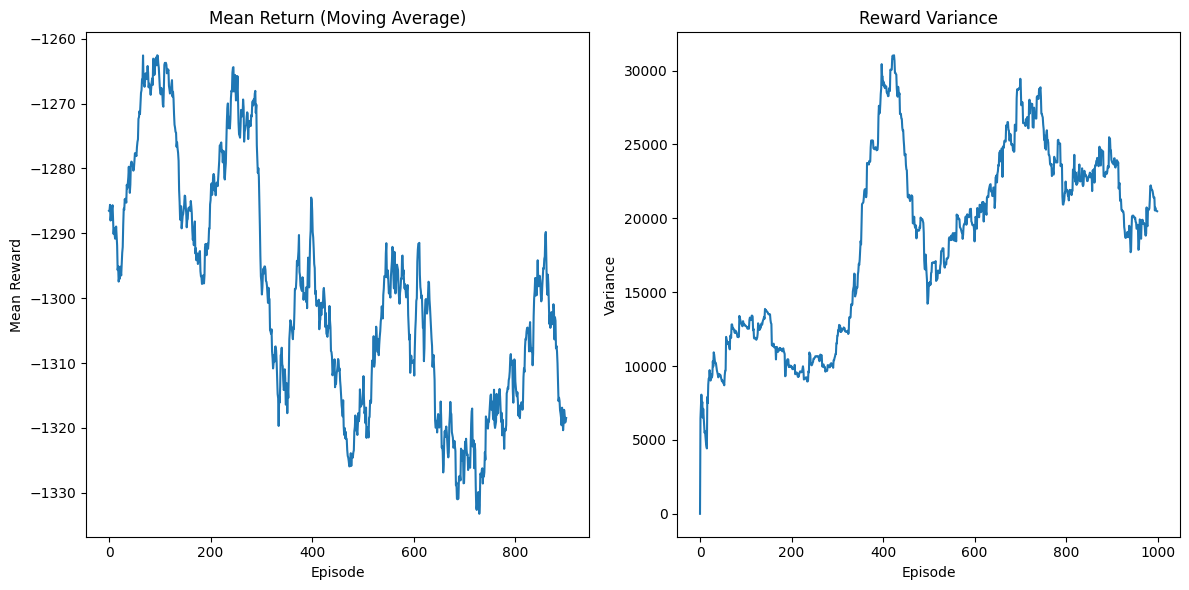

In [18]:
def plot_learning_curve():
    if len(episode_rewards) < 2:  
        print("Not enough data to plot learning curve.")
        return
    
    window_size = 100
    mean_rewards = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
    reward_variance = [np.var(episode_rewards[max(0, i-window_size+1):i+1]) for i in range(len(episode_rewards))]
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(mean_rewards)
    plt.title('Mean Return (Moving Average)')
    plt.xlabel('Episode')
    plt.ylabel('Mean Reward')
    
    plt.subplot(1, 2, 2)
    plt.plot(reward_variance)
    plt.title('Reward Variance')
    plt.xlabel('Episode')
    plt.ylabel('Variance')

    plt.tight_layout()
    plt.show()

plot_learning_curve()